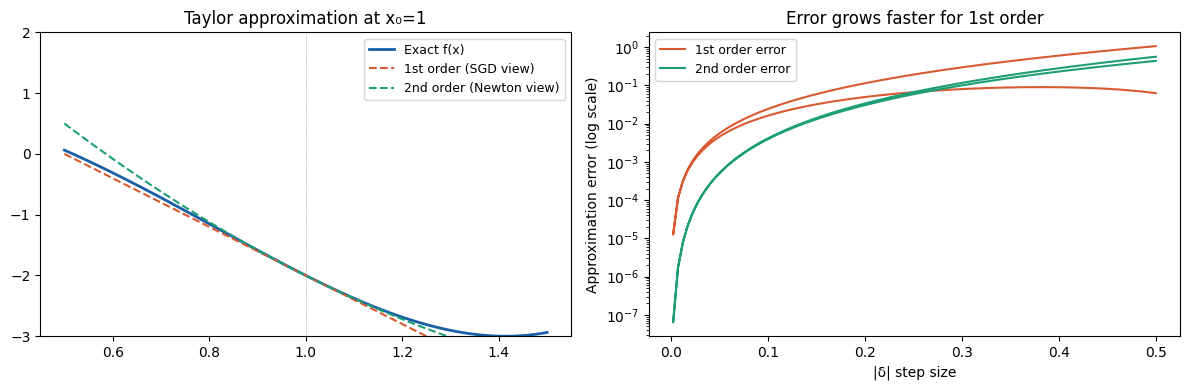

Newton converged in 10 steps: w=3.00000000
SGD after 200 steps: w=2.99977359
True minimum: w=3.0


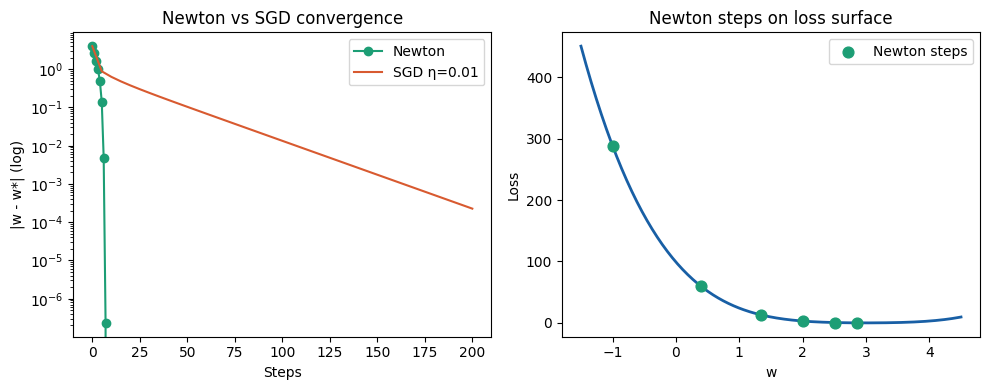

Adam from scratch: w=2.75973023 (true=3.0)
PyTorch Adam: w=2.75973058
Match: True


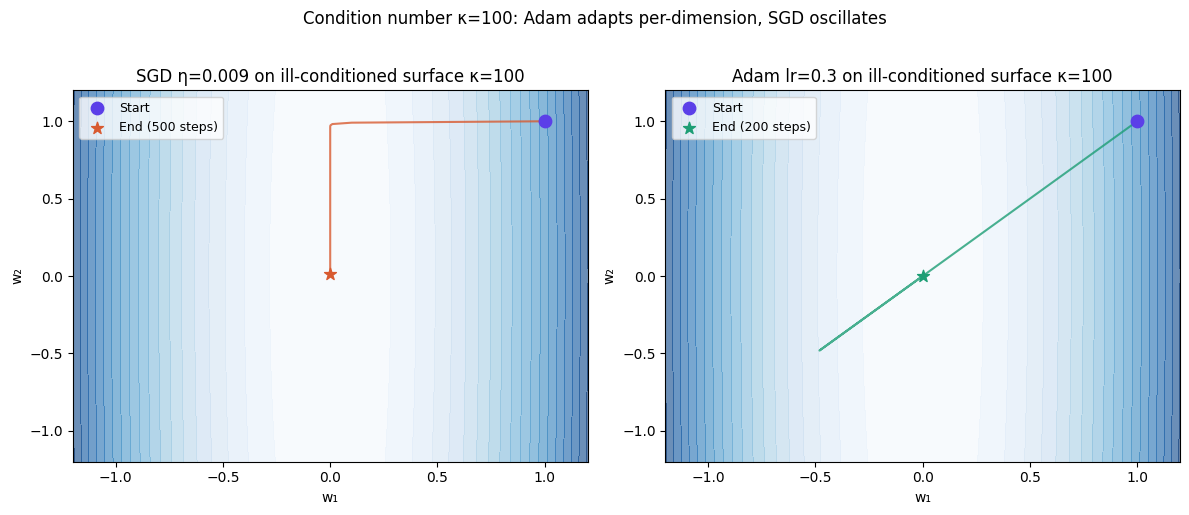

Save as day10_taylor_optimisers.ipynb && git push


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch

# ── 1. Taylor approximation accuracy ─────────────────────
def f(x):    return x**4 - 4*x**2 + 1
def df(x):   return 4*x**3 - 8*x
def ddf(x):  return 12*x**2 - 8

x0 = 1.0
deltas = np.linspace(-0.5, 0.5, 200)

approx_1st = f(x0) + df(x0)*deltas
approx_2nd = f(x0) + df(x0)*deltas + 0.5*ddf(x0)*deltas**2
exact       = f(x0 + deltas)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(x0+deltas, exact,       color='#185FA5', lw=2,   label='Exact f(x)')
ax1.plot(x0+deltas, approx_1st,  color='#D85A30', lw=1.5, ls='--', label='1st order (SGD view)')
ax1.plot(x0+deltas, approx_2nd,  color='#1D9E75', lw=1.5, ls='--', label='2nd order (Newton view)')
ax1.axvline(x0, color='gray', lw=0.5, ls=':')
ax1.set_title('Taylor approximation at x₀=1'); ax1.legend(fontsize=9)
ax1.set_ylim(-3, 2)

# Error comparison
ax2.semilogy(np.abs(deltas), np.abs(exact-approx_1st)+1e-16, color='#D85A30', label='1st order error')
ax2.semilogy(np.abs(deltas), np.abs(exact-approx_2nd)+1e-16, color='#1D9E75', label='2nd order error')
ax2.set_xlabel('|δ| step size'); ax2.set_ylabel('Approximation error (log scale)')
ax2.set_title('Error grows faster for 1st order'); ax2.legend(fontsize=9)
plt.tight_layout(); plt.show()

# ── 2. Newton's method vs SGD — 1D example ───────────────
def loss(w):    return (w - 3.0)**4 + 2*(w - 3.0)**2
def dloss(w):   return 4*(w-3)**3 + 4*(w-3)
def ddloss(w):  return 12*(w-3)**2 + 4

# Newton's method
w_n, hist_n = -1.0, [-1.0]
for _ in range(10):
    w_n = w_n - dloss(w_n) / ddloss(w_n)   # δ* = -f'/f''
    hist_n.append(w_n)

# SGD
w_s, hist_s = -1.0, [-1.0]
for _ in range(200):
    w_s = w_s - 0.01 * dloss(w_s)
    hist_s.append(w_s)

print(f"Newton converged in {len(hist_n)-1} steps: w={hist_n[-1]:.8f}")
print(f"SGD after 200 steps: w={hist_s[-1]:.8f}")
print(f"True minimum: w=3.0")

plt.figure(figsize=(10, 4))
plt.subplot(1,2,1)
plt.semilogy(range(len(hist_n)), [abs(w-3) for w in hist_n], 'o-', color='#1D9E75', label='Newton')
plt.semilogy(range(0, len(hist_s), 5), [abs(w-3) for w in hist_s[::5]], color='#D85A30', label='SGD η=0.01')
plt.xlabel('Steps'); plt.ylabel('|w - w*| (log)'); plt.legend()
plt.title('Newton vs SGD convergence')

plt.subplot(1,2,2)
w_range = np.linspace(-1.5, 4.5, 300)
plt.plot(w_range, [loss(w) for w in w_range], color='#185FA5', lw=2)
plt.scatter(hist_n[:6], [loss(w) for w in hist_n[:6]], color='#1D9E75', s=60, zorder=5, label='Newton steps')
plt.xlabel('w'); plt.ylabel('Loss'); plt.legend(); plt.title('Newton steps on loss surface')
plt.tight_layout(); plt.show()

# ── 3. Adam from scratch ─────────────────────────────────
def adam(grad_fn, w0, lr=0.01, beta1=0.9, beta2=0.999, eps=1e-8, steps=200):
    w = w0; m = 0; v = 0; hist = [w]
    for t in range(1, steps+1):
        g = grad_fn(w)
        m = beta1*m + (1-beta1)*g          # 1st moment
        v = beta2*v + (1-beta2)*g**2       # 2nd moment
        m_hat = m / (1 - beta1**t)         # bias correction
        v_hat = v / (1 - beta2**t)         # bias correction
        w = w - lr * m_hat / (np.sqrt(v_hat) + eps)
        hist.append(w)
    return w, hist

w_adam, hist_adam = adam(dloss, -1.0, lr=0.1)
print(f"Adam from scratch: w={w_adam:.8f} (true=3.0)")

# Verify against PyTorch Adam
w_t = torch.tensor([-1.0], requires_grad=True)
opt = torch.optim.Adam([w_t], lr=0.1)
hist_pt = [w_t.item()]
for _ in range(200):
    opt.zero_grad()
    l = (w_t-3)**4 + 2*(w_t-3)**2
    l.backward(); opt.step()
    hist_pt.append(w_t.item())
print(f"PyTorch Adam: w={w_t.item():.8f}")
print(f"Match: {abs(w_adam - w_t.item()) < 1e-4}")

# ── 4. Ill-conditioned surface: where Adam beats SGD ─────
# Elongated bowl: κ = 100 (condition number from Day 6)
def ill_loss(w):      return 50*w[0]**2 + 0.5*w[1]**2
def ill_grad(w):      return np.array([100*w[0], w[1]])

def run_sgd_2d(lr, steps=500):
    w = np.array([1.0, 1.0]); path = [w.copy()]
    for _ in range(steps):
        w = w - lr * ill_grad(w); path.append(w.copy())
    return np.array(path)

def run_adam_2d(lr=0.1, steps=200):
    w = np.array([1.0, 1.0])
    m = np.zeros(2); v = np.zeros(2); path = [w.copy()]
    for t in range(1, steps+1):
        g = ill_grad(w)
        m = 0.9*m + 0.1*g; v = 0.999*v + 0.001*g**2
        mh = m/(1-0.9**t); vh = v/(1-0.999**t)
        w = w - lr*mh/(np.sqrt(vh)+1e-8); path.append(w.copy())
    return np.array(path)

path_sgd  = run_sgd_2d(lr=0.009)
path_adam = run_adam_2d(lr=0.3)

w1 = np.linspace(-1.2, 1.2, 200); w2 = np.linspace(-1.2, 1.2, 200)
W1, W2 = np.meshgrid(w1, w2)
Z = 50*W1**2 + 0.5*W2**2

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, path, name, col in [(axes[0],path_sgd,'SGD η=0.009','#D85A30'),
                              (axes[1],path_adam,'Adam lr=0.3','#1D9E75')]:
    ax.contourf(W1, W2, Z, levels=20, cmap='Blues', alpha=0.6)
    ax.plot(path[:,0], path[:,1], '-', color=col, lw=1.5, alpha=0.8)
    ax.scatter(*path[0],  color='#5B3FE8', s=80, zorder=5, label='Start')
    ax.scatter(*path[-1], color=col, s=80, marker='*', zorder=5, label=f'End ({len(path)-1} steps)')
    ax.set_title(f'{name} on ill-conditioned surface κ=100')
    ax.legend(fontsize=9); ax.set_xlabel('w₁'); ax.set_ylabel('w₂')
plt.suptitle('Condition number κ=100: Adam adapts per-dimension, SGD oscillates', y=1.02)
plt.tight_layout(); plt.show()
print("Save as day10_taylor_optimisers.ipynb && git push")